<div style="background:linear-gradient(135deg,#1a1a2e,#0f3460);padding:32px 40px;border-radius:12px;color:white;font-family:sans-serif;">
<h1 style="margin:0;font-size:1.9em;">🔬 BUSI Breast Ultrasound — Multiclass Classification</h1>
<p style="opacity:0.85;margin-top:8px;">Structured comparison · Baseline · Augmentation · Oversampling · Focal Loss</p>
<hr style="border-color:rgba(255,255,255,0.2);margin:14px 0;"/>
<table style="color:white;font-size:0.9em;"><tr><td style="padding:3px 18px 3px 0"><b>Dataset</b></td><td>BUSI — 780 PNG · 3 classes</td></tr>
<tr><td><b>Backbone</b></td><td>ResNet-18 (ImageNet pretrained)</td></tr>
<tr><td><b>Classes</b></td><td>benign 487 · malignant 210 · normal 133</td></tr>
<tr><td><b>Imbalance Ratio</b></td><td>benign is 3.7× more frequent than normal</td></tr></table></div>

## 1. Setup & Imports

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Subset

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

PyTorch : 2.9.0+cu126
Device  : cuda
GPU     : Tesla P100-PCIE-16GB


## 2. Configuration

In [2]:
DATA_PATH  = '/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'
CLASSES    = ['benign', 'malignant', 'normal']
N_CLASSES  = 3
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-4
VAL_SPLIT  = 0.20       # 80% train / 20% test
FOCAL_GAMMA = 2.0
print('Config ready ✅')

Config ready ✅


## 3. Dataset Loading & EDA

In [3]:
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

full_dataset = datasets.ImageFolder(DATA_PATH, transform=base_transform)
# Filter out ground-truth mask files
full_dataset.samples = [(p,l) for p,l in full_dataset.samples if '_mask' not in p]
full_dataset.targets = [l for _,l in full_dataset.samples]

counts = np.bincount(full_dataset.targets)
print(f'Total  : {len(full_dataset)} images')
for cls, cnt in zip(CLASSES, counts):
    print(f'  {cls:12s}: {cnt:4d}  ({cnt/len(full_dataset)*100:.1f}%)')

Total  : 780 images
  benign      :  437  (56.0%)
  malignant   :  210  (26.9%)
  normal      :  133  (17.1%)


## 4. Shared Utilities (Model · Loss · Train · Evaluate)

In [5]:
def get_model():
    """Returns a fresh ResNet-18 with 3-class head."""
    m = torchvision.models.resnet18(weights='IMAGENET1K_V1')
    m.fc = nn.Linear(m.fc.in_features, N_CLASSES)
    return m.to(device)

print(f'ResNet-18 params: {sum(p.numel() for p in get_model().parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


ResNet-18 params: 11,178,051


In [6]:
class FocalLoss(nn.Module):
    """
    FL(p_t) = -(1-p_t)^gamma * log(p_t)
    gamma=0  →  standard CrossEntropy
    gamma>0  →  downweights easy examples, focuses on hard ones
    """
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

print('FocalLoss ready ✅')

FocalLoss ready ✅


In [7]:
def train_model(train_loader, criterion, label=''):
    model     = get_model()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    history   = {'train_loss':[], 'train_acc':[]}

    print(f'\n{"─"*52}')
    print(f'  {label}')
    print(f'{"─"*52}')

    for epoch in range(EPOCHS):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward(); optimizer.step()
            run_loss += loss.item()
            _, preds  = torch.max(out, 1)
            correct  += (preds == lbls).sum().item()
            total    += lbls.size(0)
        scheduler.step()
        eloss = run_loss / len(train_loader)
        eacc  = correct / total
        history['train_loss'].append(eloss)
        history['train_acc'].append(eacc)
        print(f'  Epoch {epoch+1:2}/{EPOCHS}  loss={eloss:.4f}  acc={eacc:.4f}')

    return model, history

print('train_model() ready ✅')

train_model() ready ✅


In [8]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            probs = F.softmax(out, dim=1)
            _, preds = torch.max(out, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    y_bin = label_binarize(all_labels, classes=list(range(N_CLASSES)))

    return {
        'accuracy' : accuracy_score(all_labels, all_preds),
        'macro_f1' : f1_score(all_labels, all_preds, average='macro'),
        'macro_auc': roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro'),
        'preds'    : all_preds, 'labels': all_labels, 'probs': all_probs,
        'report'   : classification_report(all_labels, all_preds,
                                           target_names=CLASSES, digits=4),
        'cm'       : confusion_matrix(all_labels, all_preds)
    }

print('evaluate_model() ready ✅')

evaluate_model() ready ✅


In [9]:
# Fixed train / test indices — reused across ALL experiments
n_total = len(full_dataset)
n_test  = int(VAL_SPLIT * n_total)
n_train = n_total - n_test
gen = torch.Generator().manual_seed(SEED)
train_idx, test_idx = random_split(range(n_total), [n_train, n_test], generator=gen)
train_idx, test_idx = list(train_idx), list(test_idx)

test_loader = DataLoader(Subset(full_dataset, test_idx),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'Train: {len(train_idx)}  |  Test: {len(test_idx)}')
print('Shared test_loader ready ✅')

Train: 624  |  Test: 156
Shared test_loader ready ✅


---
## 5. Experiment 1 — Baseline

> **Loss:** `CrossEntropyLoss` &nbsp;|&nbsp; **Data:** No augmentation, no balancing  
> **Purpose:** Reference point. Majority class (benign) will likely dominate.


In [10]:
train_loader_base = DataLoader(Subset(full_dataset, train_idx),
                                batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f'Baseline: {len(train_loader_base)} train batches')

Baseline: 20 train batches


In [11]:
baseline_model, baseline_history = train_model(
    train_loader_base, nn.CrossEntropyLoss(), label='Baseline')


────────────────────────────────────────────────────
  Baseline
────────────────────────────────────────────────────
  Epoch  1/10  loss=0.7501  acc=0.6506
  Epoch  2/10  loss=0.1364  acc=0.9808
  Epoch  3/10  loss=0.0393  acc=0.9968
  Epoch  4/10  loss=0.0153  acc=0.9984
  Epoch  5/10  loss=0.0140  acc=0.9968
  Epoch  6/10  loss=0.0116  acc=0.9968
  Epoch  7/10  loss=0.0082  acc=0.9984
  Epoch  8/10  loss=0.0108  acc=0.9984
  Epoch  9/10  loss=0.0099  acc=0.9984
  Epoch 10/10  loss=0.0079  acc=0.9968


In [12]:
baseline_metrics = evaluate_model(baseline_model, test_loader)
print(f'Acc={baseline_metrics["accuracy"]:.4f}  F1={baseline_metrics["macro_f1"]:.4f}  AUC={baseline_metrics["macro_auc"]:.4f}')
print(baseline_metrics['report'])

Acc=0.8526  F1=0.8428  AUC=0.9513
              precision    recall  f1-score   support

      benign     0.8132    0.9487    0.8757        78
   malignant     0.8947    0.7556    0.8193        45
      normal     0.9259    0.7576    0.8333        33

    accuracy                         0.8526       156
   macro avg     0.8779    0.8206    0.8428       156
weighted avg     0.8606    0.8526    0.8505       156



---
## 6. Experiment 2 — Data Augmentation

> **Transforms:** RandomHorizontalFlip · RandomVerticalFlip · RandomRotation(15°) · RandomResizedCrop · ColorJitter · GaussianBlur  
> **Effect:** Synthetically expands minority classes; improves model generalisation.


In [13]:
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

aug_dataset = datasets.ImageFolder(DATA_PATH, transform=aug_transform)
aug_dataset.samples = [(p,l) for p,l in aug_dataset.samples if '_mask' not in p]
aug_dataset.targets = [l for _,l in aug_dataset.samples]

train_loader_aug = DataLoader(Subset(aug_dataset, train_idx),
                               batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f'Augmentation: {len(train_loader_aug)} train batches')

Augmentation: 20 train batches


In [15]:
aug_model, aug_history = train_model(
    train_loader_aug, nn.CrossEntropyLoss(), label='Data Augmentation')


────────────────────────────────────────────────────
  Data Augmentation
────────────────────────────────────────────────────
  Epoch  1/10  loss=0.8381  acc=0.6138
  Epoch  2/10  loss=0.5718  acc=0.7676
  Epoch  3/10  loss=0.4792  acc=0.8189
  Epoch  4/10  loss=0.4135  acc=0.8333
  Epoch  5/10  loss=0.3686  acc=0.8654
  Epoch  6/10  loss=0.3157  acc=0.8782
  Epoch  7/10  loss=0.2667  acc=0.9006
  Epoch  8/10  loss=0.2590  acc=0.9006
  Epoch  9/10  loss=0.2540  acc=0.9103
  Epoch 10/10  loss=0.2361  acc=0.9135


In [16]:
aug_metrics = evaluate_model(aug_model, test_loader)
print(f'Acc={aug_metrics["accuracy"]:.4f}  F1={aug_metrics["macro_f1"]:.4f}  AUC={aug_metrics["macro_auc"]:.4f}')
print(aug_metrics['report'])

Acc=0.9167  F1=0.9120  AUC=0.9684
              precision    recall  f1-score   support

      benign     0.8837    0.9744    0.9268        78
   malignant     0.9302    0.8889    0.9091        45
      normal     1.0000    0.8182    0.9000        33

    accuracy                         0.9167       156
   macro avg     0.9380    0.8938    0.9120       156
weighted avg     0.9217    0.9167    0.9160       156



---
## 7. Experiment 3 — Oversampling (WeightedRandomSampler)

> **Mechanism:** Assign weight = 1/class_count to each training sample.  
> The sampler draws batches with approximately balanced class representation every epoch.


In [17]:
train_targets  = [full_dataset.targets[i] for i in train_idx]
class_counts   = np.bincount(train_targets)
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_targets]

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_over = DataLoader(Subset(full_dataset, train_idx),
                                batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
print('Class weights:', {c: f'{w:.5f}' for c,w in zip(CLASSES, class_weights)})

# Verify balance in first 200 samples
sample_lbls = []
for _, l in train_loader_over:
    sample_lbls.extend(l.numpy())
    if len(sample_lbls) >= 200: break
sampled_counts = np.bincount(sample_lbls[:200])
print('First 200 sampled:', {c: int(n) for c,n in zip(CLASSES, sampled_counts)})

Class weights: {'benign': '0.00279', 'malignant': '0.00606', 'normal': '0.01000'}
First 200 sampled: {'benign': 66, 'malignant': 74, 'normal': 60}


In [18]:
over_model, over_history = train_model(
    train_loader_over, nn.CrossEntropyLoss(), label='Oversampling (WeightedRandomSampler)')


────────────────────────────────────────────────────
  Oversampling (WeightedRandomSampler)
────────────────────────────────────────────────────
  Epoch  1/10  loss=0.5779  acc=0.7484
  Epoch  2/10  loss=0.1566  acc=0.9535
  Epoch  3/10  loss=0.1270  acc=0.9615
  Epoch  4/10  loss=0.0413  acc=0.9984
  Epoch  5/10  loss=0.0456  acc=0.9904
  Epoch  6/10  loss=0.0155  acc=0.9968
  Epoch  7/10  loss=0.0151  acc=0.9984
  Epoch  8/10  loss=0.0133  acc=0.9984
  Epoch  9/10  loss=0.0102  acc=1.0000
  Epoch 10/10  loss=0.0065  acc=1.0000


In [19]:
over_metrics = evaluate_model(over_model, test_loader)
print(f'Acc={over_metrics["accuracy"]:.4f}  F1={over_metrics["macro_f1"]:.4f}  AUC={over_metrics["macro_auc"]:.4f}')
print(over_metrics['report'])

Acc=0.8397  F1=0.8306  AUC=0.9422
              precision    recall  f1-score   support

      benign     0.7789    0.9487    0.8555        78
   malignant     0.9189    0.7556    0.8293        45
      normal     0.9583    0.6970    0.8070        33

    accuracy                         0.8397       156
   macro avg     0.8854    0.8004    0.8306       156
weighted avg     0.8573    0.8397    0.8377       156



---
## 8. Experiment 4 — Focal Loss

> **Formula:** `FL(p_t) = −(1−p_t)^γ · log(p_t)` with γ=2  
> **Effect:** Easy, well-classified examples contribute near-zero gradient.  
> Hard, misclassified examples (often minority classes) dominate the update.


In [21]:
focal_model, focal_history = train_model(
    train_loader_base,          # same data as baseline — only loss changes
    criterion=FocalLoss(gamma=FOCAL_GAMMA),
    label=f'Focal Loss (γ={FOCAL_GAMMA})')


────────────────────────────────────────────────────
  Focal Loss (γ=2.0)
────────────────────────────────────────────────────
  Epoch  1/10  loss=0.2712  acc=0.7228
  Epoch  2/10  loss=0.0356  acc=0.9744
  Epoch  3/10  loss=0.0100  acc=0.9968
  Epoch  4/10  loss=0.0044  acc=0.9968
  Epoch  5/10  loss=0.0029  acc=0.9968
  Epoch  6/10  loss=0.0017  acc=0.9984
  Epoch  7/10  loss=0.0018  acc=0.9984
  Epoch  8/10  loss=0.0018  acc=0.9984
  Epoch  9/10  loss=0.0021  acc=1.0000
  Epoch 10/10  loss=0.0034  acc=0.9968


In [22]:
focal_metrics = evaluate_model(focal_model, test_loader)
print(f'Acc={focal_metrics["accuracy"]:.4f}  F1={focal_metrics["macro_f1"]:.4f}  AUC={focal_metrics["macro_auc"]:.4f}')
print(focal_metrics['report'])

Acc=0.8654  F1=0.8577  AUC=0.9495
              precision    recall  f1-score   support

      benign     0.8152    0.9615    0.8824        78
   malignant     0.9211    0.7778    0.8434        45
      normal     0.9615    0.7576    0.8475        33

    accuracy                         0.8654       156
   macro avg     0.8993    0.8323    0.8577       156
weighted avg     0.8767    0.8654    0.8637       156



---
## 9. Evaluation — Per-Experiment Plots

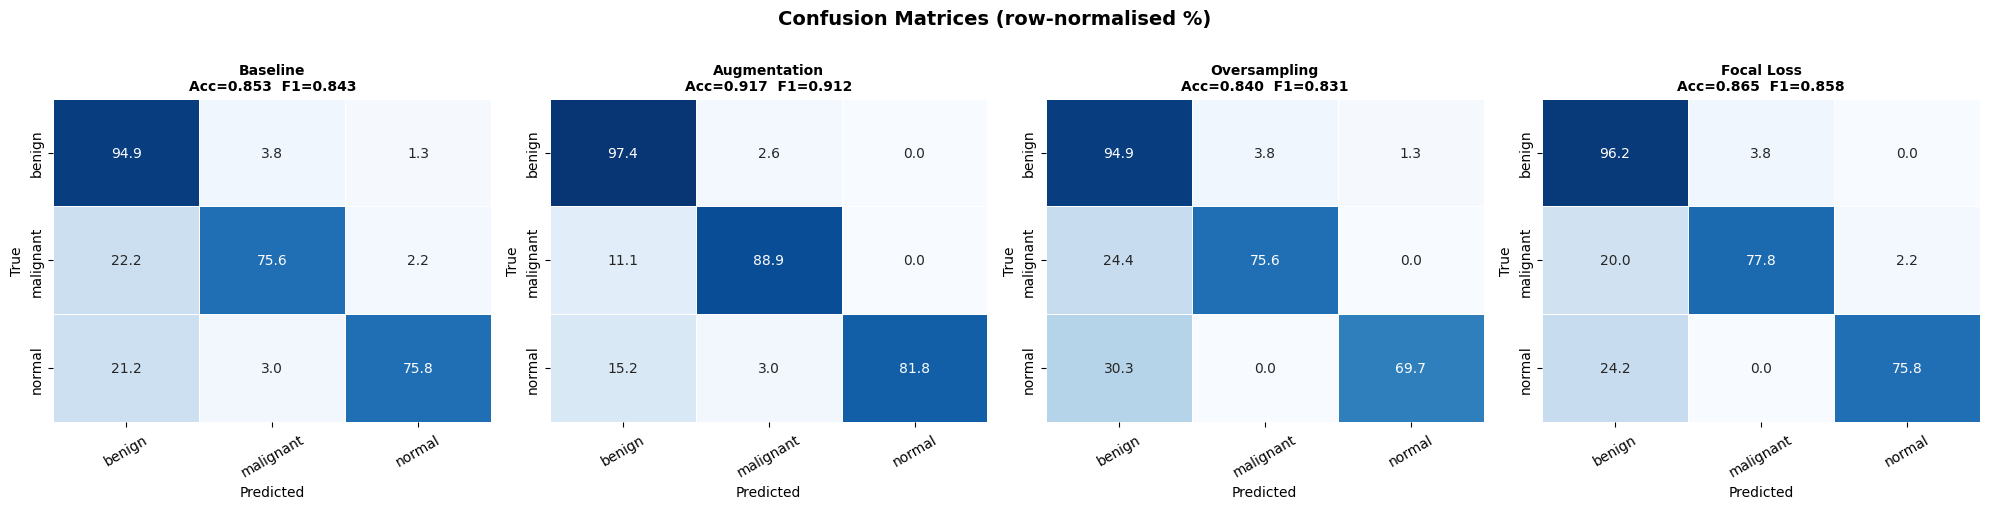

In [23]:
experiments = [
    ('Baseline',     baseline_metrics),
    ('Augmentation', aug_metrics),
    ('Oversampling', over_metrics),
    ('Focal Loss',   focal_metrics),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices (row-normalised %)', fontsize=14, fontweight='bold', y=1.01)
for ax, (name, m) in zip(axes, experiments):
    cm_pct = m['cm'].astype(float) / m['cm'].sum(axis=1,keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.5, cbar=False, vmin=0, vmax=100)
    ax.set_title(f'{name}\nAcc={m["accuracy"]:.3f}  F1={m["macro_f1"]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

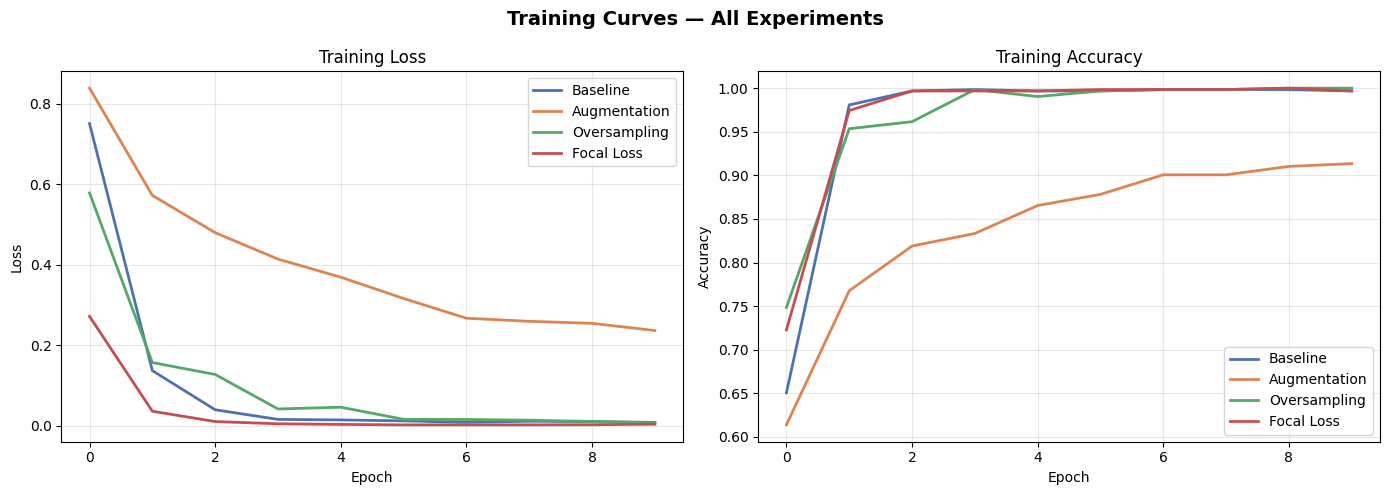

In [25]:
histories = [
    ('Baseline',     baseline_history, '#4C72B0'),
    ('Augmentation', aug_history,      '#DD8452'),
    ('Oversampling', over_history,     '#55A868'),
    ('Focal Loss',   focal_history,    '#C44E52'),
]
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Training Curves — All Experiments', fontsize=14, fontweight='bold')
for name,h,c in histories:
    ax1.plot(h['train_loss'], label=name, color=c, lw=2)
    ax2.plot(h['train_acc'],  label=name, color=c, lw=2)
ax1.set(xlabel='Epoch',ylabel='Loss',title='Training Loss')
ax2.set(xlabel='Epoch',ylabel='Accuracy',title='Training Accuracy')
ax1.legend(); ax2.legend()
ax1.grid(alpha=0.3); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10. Summary Table & Final Comparison

In [26]:
rows = []
for name, m in experiments:
    pf = f1_score(m['labels'], m['preds'], average=None)
    rows.append({
        'Experiment'    : name,
        'Accuracy'      : round(m['accuracy'],  4),
        'Macro F1'      : round(m['macro_f1'],  4),
        'Macro AUC'     : round(m['macro_auc'], 4),
        'F1 benign'     : round(pf[0], 4),
        'F1 malignant'  : round(pf[1], 4),
        'F1 normal'     : round(pf[2], 4),
    })

df = pd.DataFrame(rows).set_index('Experiment')
print(df.to_string())

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color:#d4edda;font-weight:bold' if v else '' for v in is_max]
df.style.apply(highlight_max, axis=0)

              Accuracy  Macro F1  Macro AUC  F1 benign  F1 malignant  F1 normal
Experiment                                                                     
Baseline        0.8526    0.8428     0.9513     0.8757        0.8193     0.8333
Augmentation    0.9167    0.9120     0.9684     0.9268        0.9091     0.9000
Oversampling    0.8397    0.8306     0.9422     0.8555        0.8293     0.8070
Focal Loss      0.8654    0.8577     0.9495     0.8824        0.8434     0.8475


,Accuracy,Macro F1,Macro AUC,F1 benign,F1 malignant,F1 normal
Experiment,,,,,,
Baseline,0.852600,0.842800,0.951300,0.875700,0.819300,0.833300
Augmentation,0.916700,0.912000,0.968400,0.926800,0.909100,0.900000
Oversampling,0.839700,0.830600,0.942200,0.855500,0.829300,0.807000
Focal Loss,0.865400,0.857700,0.949500,0.882400,0.843400,0.847500
